# Depth Estimation and Decision Architecture

This notebook provides a detailed overview of the core safety layers of the Autonomous Navigation Safety System:
1. **Depth Estimation** using MiDaS (`src/core/depth.py`)
2. **Safety Intervention Engine** (`src/core/decision.py`)

## 1. Depth Estimation (`src/core/depth.py`)
### Overview
The system uses **MiDaS v2.1 Small** for monocular depth estimation. It maps a single RGB frame to a normalized depth map (0–255), where **higher values indicate closer objects** (brightness = closeness).

### Key Features
*   **Frame-Skip Cooldown:** To maintain a high frame rate, the model isn't run on every frame. Instead, it runs every $N$-th frame (configurable via `skip_frames`), and the cached depth map is reused for intermediate frames.
*   **Bounding Box Depth Sampling:** The `sample_depth` method estimates the distance to a specific detected object by taking the **median** depth within a small central patch ($10 \times 10$ pixels by default) of its bounding box, which provides robustness against depth noise.
*   **Transformations:** Uses `small_transform` expected by MiDaS to preprocess frames before they are fed into the network.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Note: Running this will download the MiDaS weights if they are not already cached.
from src.core.depth import DepthEstimator

# Initialize the Depth Estimator
# Using skip_frames=3 means inference runs every 3rd frame
depth_estimator = DepthEstimator(skip_frames=3)

print("MiDaS model loaded successfully!")

[INFO] Loading MiDaS v2.1 Small (this may download weights on first run) …


Using cache found in C:\Users\yusuf/.cache\torch\hub\intel-isl_MiDaS_master
d:\work\freelance\Autonomous-Navigation-Safety-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\work\freelance\Autonomous-Navigation-Safety-System\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\yusuf/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


MiDaS model loaded successfully!


Using cache found in C:\Users\yusuf/.cache\torch\hub\intel-isl_MiDaS_master


### Depth Estimation Visualization
Let's fetch a sample image of a corridor and run our setup to see how the depth map is generated:

In [ ]:
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Download a sample indoor image (corridor)
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Empty_corridor.jpg/640px-Empty_corridor.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)

# Infer depth map using MiDaS
depth_map = depth_estimator.infer(img)

# Colorise the depth map using the function provided in `depth.py`
colored_depth = depth_estimator.colorise(depth_map)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original RGB Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(colored_depth, cv2.COLOR_BGR2RGB))
axes[1].set_title("Depth Map (Closer = Brighter)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## 2. Decision Engine Architecture (`src/core/decision.py`)
### Overview
The `SafetyIntervention` class is a rule-based engine mapping detected objects and their estimated distances to real-time navigational control flags: `STOP`, `AVOID LEFT`, `AVOID RIGHT`, or `GO`.

### How Decisions Are Made
1.  **Critical Zone Check:**
    The image is split vertically. A **Critical Zone** is defined in the center of the frame (e.g., middle 40%).
    *   Objects outside the critical zone are **ignored** (they do not pose an immediate forward threat).
    *   Only detections whose bounding box center falls within this `[zone_left, zone_right]` band are processed.

2.  **Distance Evaluation (Closest First):**
    For objects in the critical zone, they are sorted by proximity. The closest object triggers the primary rule:
    *   **STOP:** If the object is closer than `stop_distance` (e.g., 1.5m).
    *   **AVOID:** If the object is between `stop_distance` and `avoid_distance` (e.g., 3.0m).
    *   **GO:** If the closest object is further than `avoid_distance`, or if there are no objects in the critical zone.

3.  **Weighted Escape Direction (Left vs. Right):**
    If the decision is `AVOID`, the system calculates a heavily weighted threat score for both the left and right halves of the screen based on *all* detections.
    *   Weight for each detection = $1 / \text{distance}^2$
    *   The system sums the weights of objects left of the midpoint and right of the midpoint.
    *   It commands the vehicle to route towards the side with the **LOWER** total threat weight (the "clearer" side).

4.  **Temporal Smoothing:**
    To prevent split-second flickering of commands (e.g., GO -> STOP -> GO), decisions are placed in a rolling queue of the last $N$ frames (`smoothing_window`).
    *   The final output flag is the **mode** (most frequent occurrence) in that window.

5.  **Depth Map Fallback (Obstruction Check):**
    If YOLO fails to detect an object, but a large wall is blocking the path, the engine checks the depth map directly. If a large percentage of the critical strip contains pixels brighter than `obstruction_threshold` (i.e., very close objects), it overrides and emits `STOP: OBSTRUCTION`.

In [2]:
from src.core.decision import SafetyIntervention

# Initialize Decision Engine
decision_engine = SafetyIntervention(
    frame_width=640,
    critical_zone_pct=0.40,  # Middle 40% of screen is critical
    stop_distance=1.5,       # Stop if closer than 1.5m
    avoid_distance=3.0,      # Avoid if between 1.5m and 3.0m
    smoothing_window=5       # Temporal smoothing over 5 frames
)

# Let's mock a scenario with a 640x480 frame
# Critical zone boundaries for 640 width with 40% pct:
# Left: 640 * ((1 - 0.4) / 2) = 192
# Right: 640 * (1 - ((1 - 0.4) / 2)) = 448

mock_detections = [
    {
        "bbox": [50, 100, 150, 200], # Center x = 100 (Outside left, safe)
        "distance": 0.5
    },
    {
        "bbox": [280, 100, 360, 200], # Center x = 320 (Inside critical zone)
        "distance": 2.5               # Avoid range (between 1.5 and 3.0)
    },
    {
        "bbox": [500, 100, 600, 200], # Center x = 550 (Outside right, safe)
        "distance": 1.0
    }
]

# Process decision
# The system should pick up the middle detection as the primary threat.
# Left weight: 1 / (0.5^2) = 4.0
# Right weight: 1 / (1.0^2) = 1.0
# Since Right weight < Left weight, system should suggest AVOID RIGHT

result = decision_engine.process(mock_detections)

print(f"Recommended Action: {result['flag']}")
print(f"Flag Color: {result['color']}")
print(f"Driven by Detection: {result['closest']}")

Recommended Action: AVOID RIGHT
Flag Color: (0, 200, 255)
Driven by Detection: {'bbox': [280, 100, 360, 200], 'distance': 2.5}


### Decision Engine Visualization
Visualizing the mock scenario above. The middle bounding box lies within the `Critical Zone` and poses the primary threat, and the model correctly weights the safer side to command `AVOID RIGHT`.

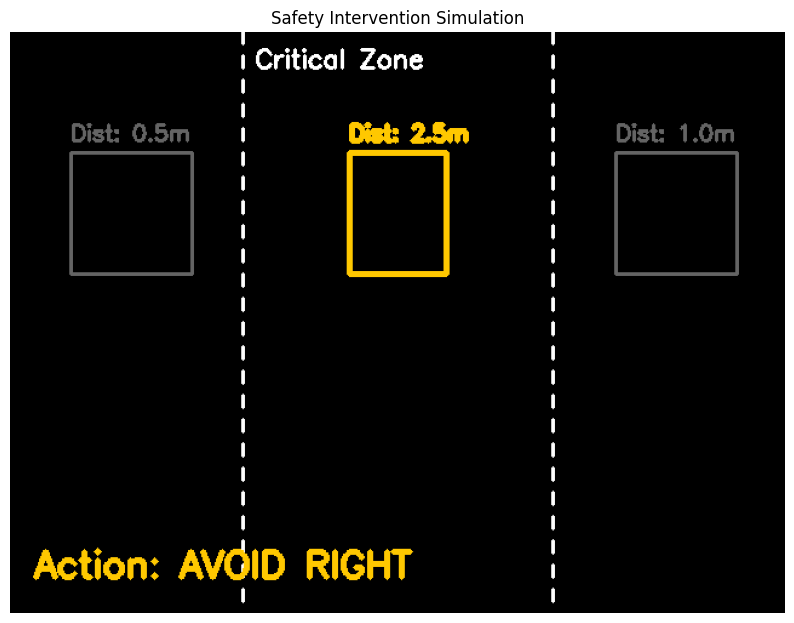

In [3]:
# Create a blank black frame representing a 640x480 resolution view
frame = np.zeros((480, 640, 3), dtype=np.uint8)

# Draw Critical Zone boundaries (Dashed lines, so drawn sparsely)
for y in range(0, 480, 20):
    cv2.line(frame, (decision_engine.zone_left, y), (decision_engine.zone_left, y+10), (255, 255, 255), 2)
    cv2.line(frame, (decision_engine.zone_right, y), (decision_engine.zone_right, y+10), (255, 255, 255), 2)

cv2.putText(frame, "Critical Zone", (decision_engine.zone_left + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

# Draw Mock Detections
for det in mock_detections:
    x1, y1, x2, y2 = det["bbox"]
    dist = det["distance"]
    
    # Highlight the closest primary threat based on result
    is_closest = det == result["closest"]
    # Our decision engine uses BGR colors for flags, OpenCV draws in BGR, Matplotlib displays in RGB
    color = result["color"] if is_closest else (100, 100, 100)
    thickness = 4 if is_closest else 2
    
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(frame, f"Dist: {dist}m", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, thickness)

# Put final decision text on bottom left
cv2.putText(frame, f"Action: {result['flag']}", (20, 450), cv2.FONT_HERSHEY_SIMPLEX, 1, result["color"], 3)

# Plot the result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Safety Intervention Simulation")
plt.axis("off")
plt.show()